# Load and Explore Sum-of-Checks

Load the public [BrachioLab/sum-of-checks dataset](https://huggingface.co/datasets/BrachioLab/sum-of-checks): 53 corrected Endoscapes images and 60 SAGES images, with original CVS labels and 19 human-labeled rubric checks.

**Development data, not expert ground truth.** The rubric labels were provided by an ML PhD student trained by a surgeon. Use these annotations as development data, not as expert surgical ground truth. This caveat concerns the added rubric annotations; the original CVS labels are retained separately from their source datasets.

The examples below are saved as PNG figures and plain-text output so they are visible on GitHub. No HTML or widgets are required.

Install dependencies with `pip install datasets huggingface_hub matplotlib Pillow` (or `pip install -r requirements-hf.txt` from the repository root).

In [1]:
import json
import os
import tempfile
import textwrap
from pathlib import Path

# Keep the image-transfer cache writable on shared machines.
os.environ.setdefault("HF_XET_CACHE", str(Path(tempfile.gettempdir()) / "sumofchecks-hf-xet"))

import matplotlib.pyplot as plt
from datasets import load_dataset, disable_progress_bars
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import disable_progress_bars as disable_hub_progress_bars
from matplotlib_inline.backend_inline import set_matplotlib_formats

get_ipython().run_line_magic("matplotlib", "inline")
set_matplotlib_formats("png")
disable_progress_bars()
disable_hub_progress_bars()

REPO_ID = "BrachioLab/sum-of-checks"
REVISION = "36f0a2dced7c919d82f7f63a63c19371102ca133"
CRITERIA = ("c1", "c2", "c3")


In [2]:
# token=False loads this public dataset without requiring login credentials.
datasets_by_source = {
    "endoscapes": load_dataset(REPO_ID, "endoscapes", split="validation", revision=REVISION, token=False),
    "sages": load_dataset(REPO_ID, "sages", split="train", revision=REVISION, token=False),
}
rubric_path = hf_hub_download(
    REPO_ID, "rubrics/cvs_rubrics_v3.json", repo_type="dataset",
    revision=REVISION, token=False,
)
rubrics = json.loads(Path(rubric_path).read_text())

for source, dataset in datasets_by_source.items():
    print(f"{source}: {len(dataset)} images")
    print(f"  Source splits: {sorted(set(dataset['source_split']))}")
    print(f"  Historical annotation versions: {sorted(set(dataset['annotation_rubric_version']))}")
    print(f"  Paper few-shot examples: {sum(dataset['is_paper_few_shot'])}")
print(f"Rubric v3: {sum(len(block['items']) for block in rubrics['criteria'].values())} checks")
print(f"Revision: {REVISION}")


endoscapes: 53 images
  Source splits: ['val']
  Historical annotation versions: ['cvs_rubrics_v1']
  Paper few-shot examples: 4
sages: 60 images
  Source splits: ['train']
  Historical annotation versions: ['cvs_rubrics_v3']
  Paper few-shot examples: 0
Rubric v3: 19 checks
Revision: 36f0a2dced7c919d82f7f63a63c19371102ca133


## Fields and Provenance

`image` is a decoded PIL image from the original embedded image bytes. `cvs_labels` preserves Endoscapes's continuous labels or SAGES's majority-vote labels; `cvs_binary_labels` uses a threshold greater than 0.5. `cvs_rater_labels` preserves the three individual SAGES votes. The complete original source label record is available in `original_cvs_annotation_json`.

`rubric_labels` contains yes/no/uncertain answers keyed by check IDs. `rubrics/cvs_rubrics_v3.json` provides check text and weights. Endoscapes's historical `annotation_rubric_version` remains v1: these annotations were not newly relabeled under v3, whose wording was revised. SAGES annotations use v3.

The gallery selects distinct examples emphasizing yes, no, and uncertain rubric answers for each source. Counts in the titles describe all 19 checks. The detailed examples favor a balanced mix of answer types. These are illustrative development examples, not a representative sample or the paper's 791-frame evaluation split.

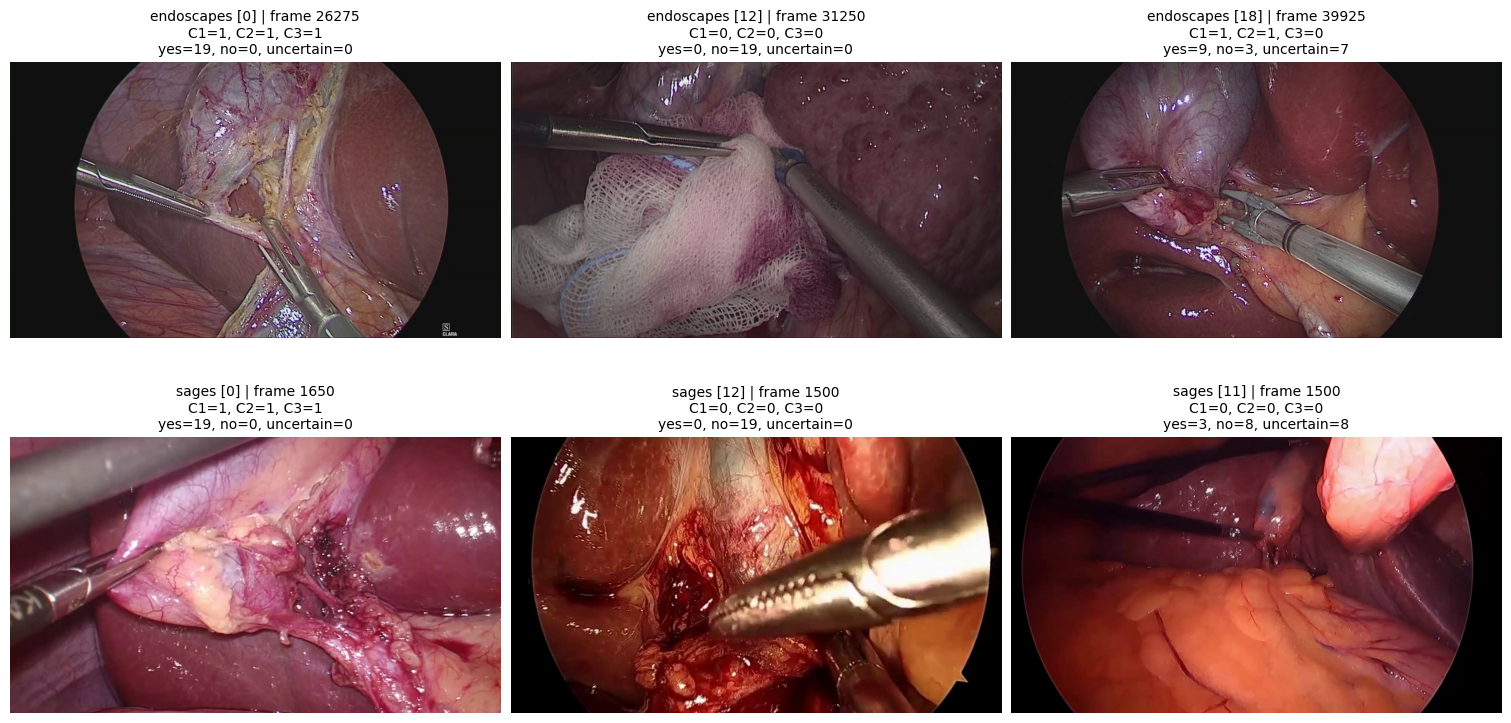

In [3]:
ANSWERS = ("yes", "no", "uncertain")

def answer_counts(labels):
    return tuple(list(labels.values()).count(answer) for answer in ANSWERS)

def diverse_indices(dataset):
    counts = [answer_counts(labels) for labels in dataset["rubric_labels"]]
    selected = []
    for answer_index in range(len(ANSWERS)):
        remaining = [i for i in range(len(dataset)) if i not in selected]
        if not remaining:
            break
        selected.append(max(remaining, key=lambda i: counts[i][answer_index]))
    return selected

def mixed_index(dataset):
    counts = [answer_counts(labels) for labels in dataset["rubric_labels"]]
    return max(range(len(dataset)), key=lambda i: (
        sum(n > 0 for n in counts[i]), min(counts[i]), -max(counts[i]),
    ))

gallery_indices = {source: diverse_indices(ds) for source, ds in datasets_by_source.items()}
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), layout="constrained")
for row_index, (source, dataset) in enumerate(datasets_by_source.items()):
    for column_index, ax in enumerate(axes[row_index]):
        ax.axis("off")
        indices = gallery_indices[source]
        if column_index >= len(indices):
            continue
        index = indices[column_index]
        example = dataset[index]
        labels = ", ".join(f"{c.upper()}={example['cvs_binary_labels'][c]}" for c in CRITERIA)
        counts = answer_counts(example["rubric_labels"])
        answers = ", ".join(f"{answer}={n}" for answer, n in zip(ANSWERS, counts))
        ax.imshow(example["image"])
        ax.set_title(
            f"{source} [{index}] | frame {example['frame_id']}\n{labels}\n{answers}",
            fontsize=10,
        )
plt.show()


## Inspect an Example

Each example below shows the image, original CVS labels, individual votes when available, and all 19 rubric answers alongside their v3 definitions. The weighted check score is computed from the surgeon-trained ML PhD student's rubric annotations; it is neither a model prediction nor expert ground truth.

Change the source and row index in the last two cells to inspect other examples.

In [4]:
def show_example(source, index):
    example = datasets_by_source[source][index]
    fig, ax = plt.subplots(figsize=(9, 5.5), layout="constrained")
    ax.imshow(example["image"])
    ax.axis("off")
    ax.set_title(f"{source} [{index}] | frame {example['frame_id']}", fontsize=12)
    plt.show()

    print(f"Example: {example['example_id']}")
    print(f"Image: {example['image_filename']} ({example['width']} x {example['height']})")
    print(f"Original CVS labels: {example['cvs_labels']}")
    print(f"Binary CVS labels:   {example['cvs_binary_labels']}")
    if any(example["cvs_rater_labels"].values()):
        print(f"Original SAGES votes (rater1, rater2, rater3): {example['cvs_rater_labels']}")
    print(f"CVS labels recorded during rubric annotation: {example['annotation_cvs_labels']}")
    print(f"Historical annotation rubric: {example['annotation_rubric_version']}")
    print(f"Bundled rubric: {example['rubric_version']}")
    print(f"Paper few-shot example: {example['is_paper_few_shot']}")

    for criterion, block in rubrics["criteria"].items():
        score = sum(
            item["weight"] * (example["rubric_labels"][item["id"]] == "yes")
            for item in block["items"]
        )
        print(f"\n{criterion}: weighted human-check score = {score:.2f} (yes=1, no/uncertain=0)")
        for item in block["items"]:
            answer = example["rubric_labels"][item["id"]]
            prefix = f"  {item['id']:5s} {answer:9s} w={item['weight']:.1f}  "
            print(textwrap.fill(prefix + item["text"], width=110, subsequent_indent=" " * len(prefix)))
    if example["annotation_notes"]:
        print("\nAnnotation notes:")
        print(textwrap.fill(example["annotation_notes"], width=110))


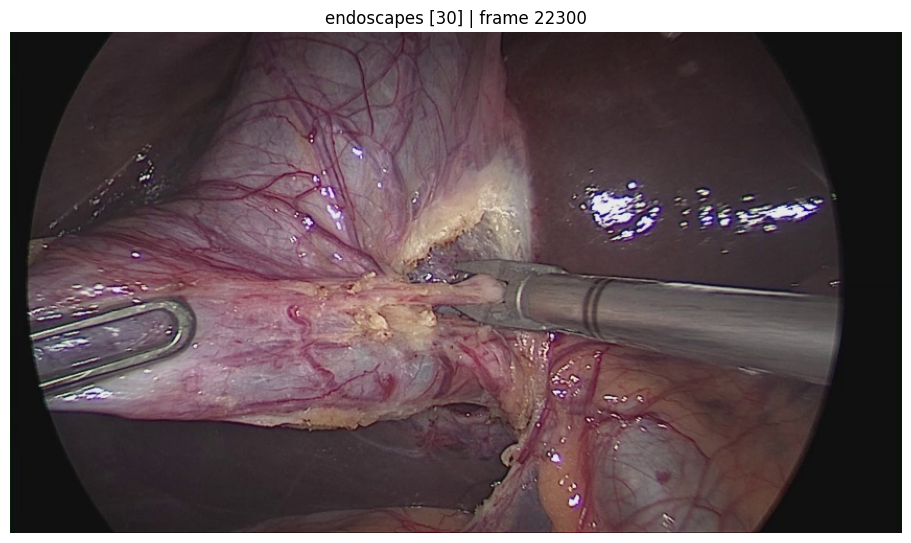

Example: endoscapes/val/148/22300
Image: 148_22300.jpg (854 x 480)
Original CVS labels: {'c1': 0.3333333333333333, 'c2': 0.0, 'c3': 0.6666666666666666}
Binary CVS labels:   {'c1': 0, 'c2': 0, 'c3': 1}
CVS labels recorded during rubric annotation: {'c1': 0.3333333333333333, 'c2': 0.0, 'c3': 0.6666666666666666}
Historical annotation rubric: cvs_rubrics_v1
Bundled rubric: cvs_rubrics_v3
Paper few-shot example: False

C1: weighted human-check score = 0.10 (yes=1, no/uncertain=0)
  C1-1  no        w=0.1  The gallbladder neck (infundibulum) region is clearly visible and in-frame.
  C1-2  no        w=0.3  There are exactly two tubular attachment tracks entering the gallbladder wall.
  C1-3  uncertain w=0.3  The two tubular structures are visually distinguishable from each other at the
                         gallbladder entry.
  C1-4  uncertain w=0.1  The gallbladder entry site is sufficiently exposed that no additional tubular
                         structure could plausibly be hidden.
  

In [5]:
show_example("endoscapes", mixed_index(datasets_by_source["endoscapes"]))

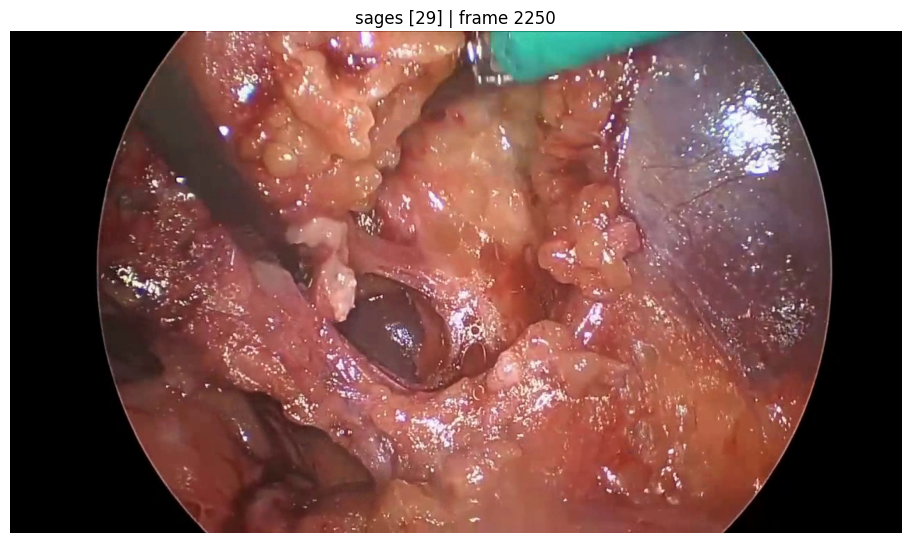

Example: sages/train/e6093fb5-236f-4856-8321-3749229eabf9/2250
Image: frame_002250.jpg (1280 x 720)
Original CVS labels: {'c1': 0.0, 'c2': 1.0, 'c3': 0.0}
Binary CVS labels:   {'c1': 0, 'c2': 1, 'c3': 0}
Original SAGES votes (rater1, rater2, rater3): {'c1': [0, 0, 1], 'c2': [0, 1, 1], 'c3': [0, 0, 1]}
CVS labels recorded during rubric annotation: {'c1': 0.0, 'c2': 1.0, 'c3': 0.0}
Historical annotation rubric: cvs_rubrics_v3
Bundled rubric: cvs_rubrics_v3
Paper few-shot example: False

C1: weighted human-check score = 0.30 (yes=1, no/uncertain=0)
  C1-1  yes       w=0.1  The gallbladder neck (infundibulum) region is clearly visible and in-frame.
  C1-2  uncertain w=0.3  There are exactly two tubular attachment tracks entering the gallbladder wall.
  C1-3  no        w=0.3  The two tubular structures are visually distinguishable from each other at the
                         gallbladder entry.
  C1-4  no        w=0.1  The gallbladder entry site is sufficiently exposed that no additional 

In [6]:
show_example("sages", mixed_index(datasets_by_source["sages"]))